# 04. Trực quan hóa kết quả

Notebook này tổng hợp các file `metrics.json` đã sinh ở những notebook trước và tạo bảng/biểu đồ dùng cho báo cáo LaTeX.

Đầu vào cần có:

- `results/runs/frozen/metrics.json`
- `results/runs/full_finetune/metrics.json`
- `results/runs/lora_r2/metrics.json`
- `results/runs/lora_r4/metrics.json`
- `results/runs/lora_r8/metrics.json`

Đầu ra được ghi vào `results/plots/`.

## Bước 1. Đặt đúng thư mục làm việc

Cell này bảo đảm notebook chạy từ thư mục `deep-learning`, giúp script visualize tìm đúng `results/runs`.

In [1]:
from pathlib import Path
import os

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
os.chdir(root)
print(f"Thư mục làm việc: {Path.cwd()}")

Thư mục làm việc: d:\HK6\Machine learning\Lab_3\csc14005-introduction-to-machine-learning\lab-3\deep-learning


## Bước 2. Sinh bảng tổng hợp và hình

Cell này gọi script `src.visualize`. Script sẽ:

1. Đọc toàn bộ `metrics.json` trong `results/runs`.
2. Gom các chỉ số chính thành `metrics.csv`.
3. Vẽ accuracy theo số tham số trainable.
4. Vẽ số tham số trainable của từng cấu hình.
5. Vẽ validation loss theo epoch.
6. Vẽ accuracy theo rank LoRA.

Nếu cell báo lỗi không tìm thấy `metrics.json`, cần chạy lại các notebook train trước.

In [2]:
import subprocess
import sys

subprocess.run(
    [sys.executable, "-m", "src.visualize", "--results", "results/runs", "--out", "results/plots"],
    check=True,
)

CompletedProcess(args=['d:\\HK6\\Machine learning\\Lab_3\\csc14005-introduction-to-machine-learning\\lab-3\\deep-learning\\.venv\\Scripts\\python.exe', '-m', 'src.visualize', '--results', 'results/runs', '--out', 'results/plots'], returncode=0)

## Bước 3. Hiển thị bảng và hình trong notebook

Cell này đọc `metrics.csv` và hiển thị bốn hình chính. Đây là bước kiểm tra trực quan trước khi copy hình vào báo cáo.

Trong lần chạy đã báo cáo, bảng kết quả có xu hướng sau:

- Full fine-tuning đạt accuracy cao nhất nhưng train toàn bộ tham số.
- LoRA rank 2 đạt accuracy tốt nhất trong các rank LoRA với rất ít tham số trainable.
- Frozen baseline nhẹ nhất nhưng accuracy thấp nhất.
- Accuracy theo rank LoRA không tăng đơn điệu trong setup nhỏ này.

,run_name,mode,rank,trainable_params,total_params,trainable_ratio,best_val_accuracy,final_val_accuracy,final_val_loss,elapsed_seconds,epochs
0,frozen,frozen,NaN,258,4386178,0.000059,0.652523,0.629587,0.643639,16.678861,3
1,full_finetune,full_finetune,NaN,4386178,4386178,1.000000,0.756881,0.756881,0.498980,56.845982,3
2,lora_r2,lora,2.0,2306,4388226,0.000525,0.724771,0.724771,0.533910,29.822125,3
3,lora_r4,lora,4.0,4354,4390274,0.000992,0.735092,0.727064,0.525230,29.783075,3
4,lora_r8,lora,8.0,8450,4394370,0.001923,0.751147,0.721330,0.528929,30.904485,3


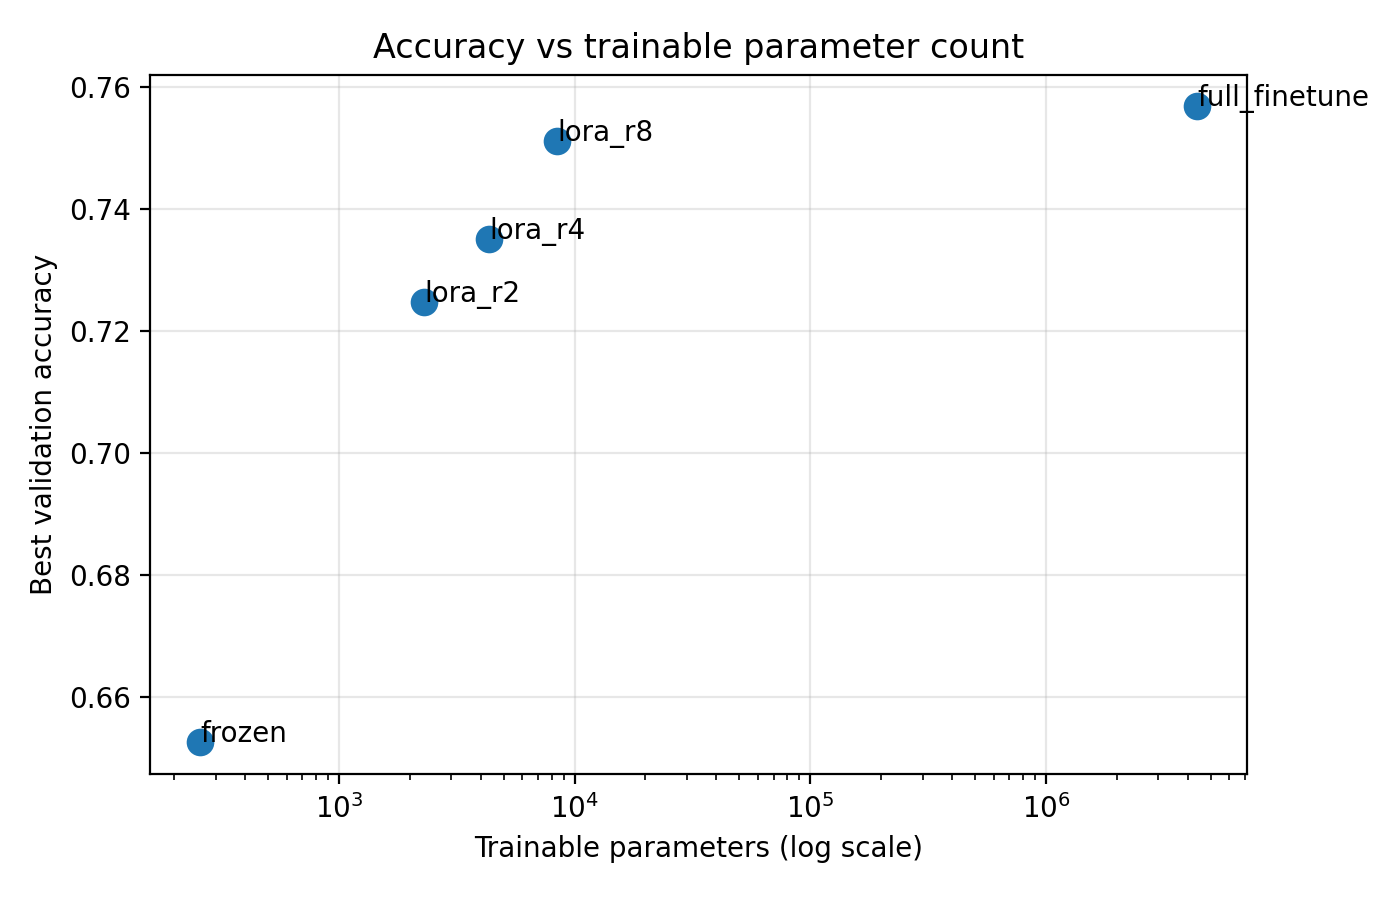

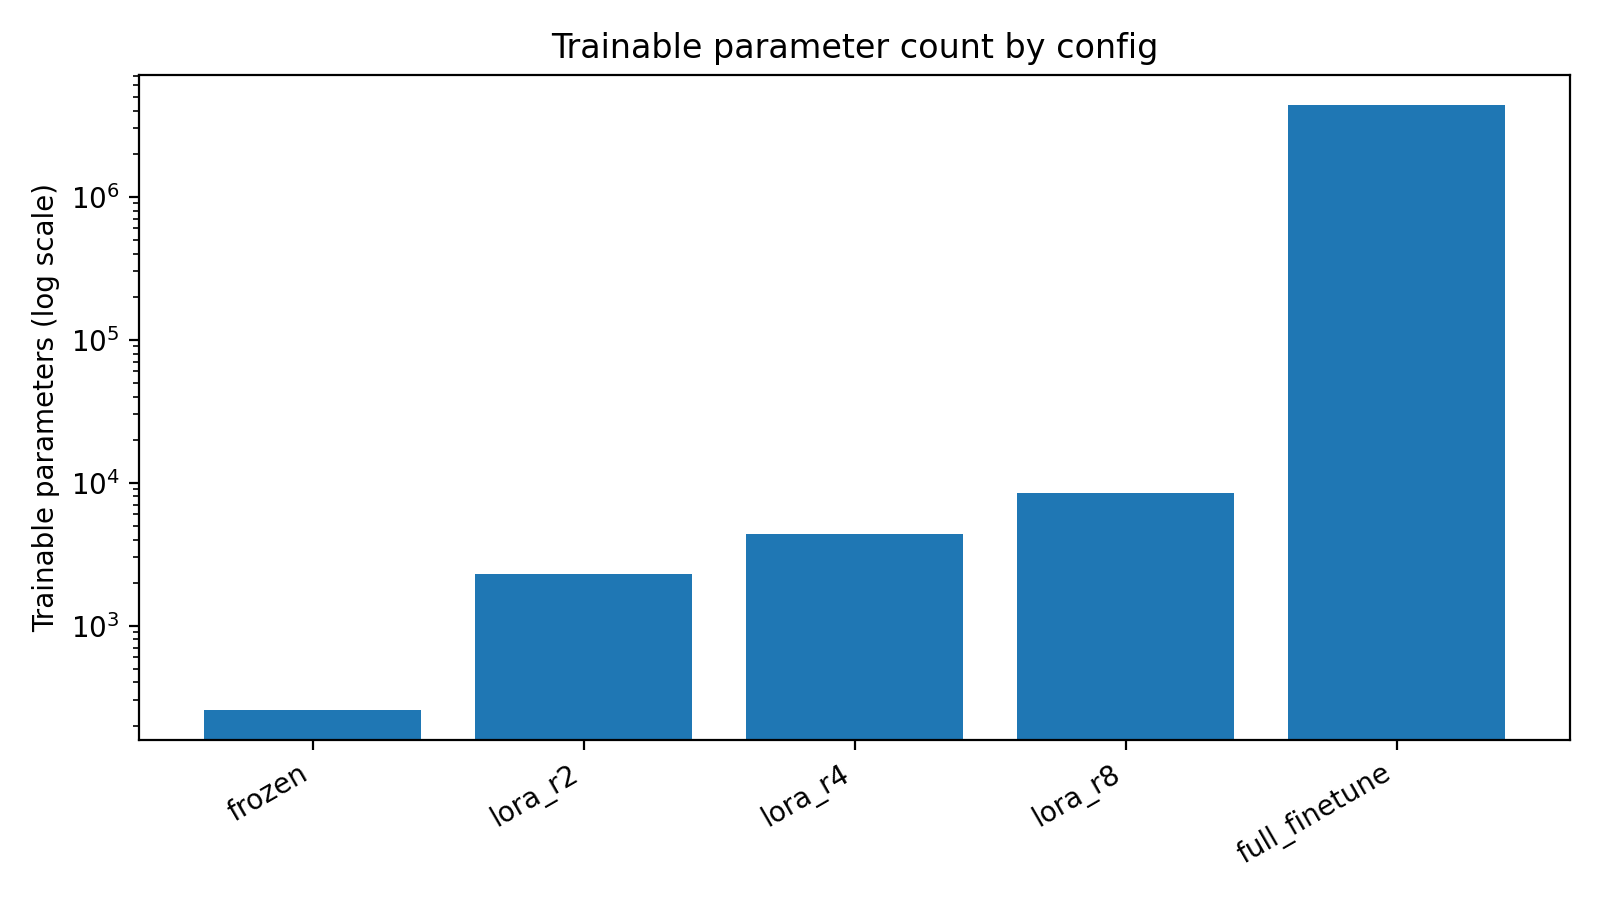

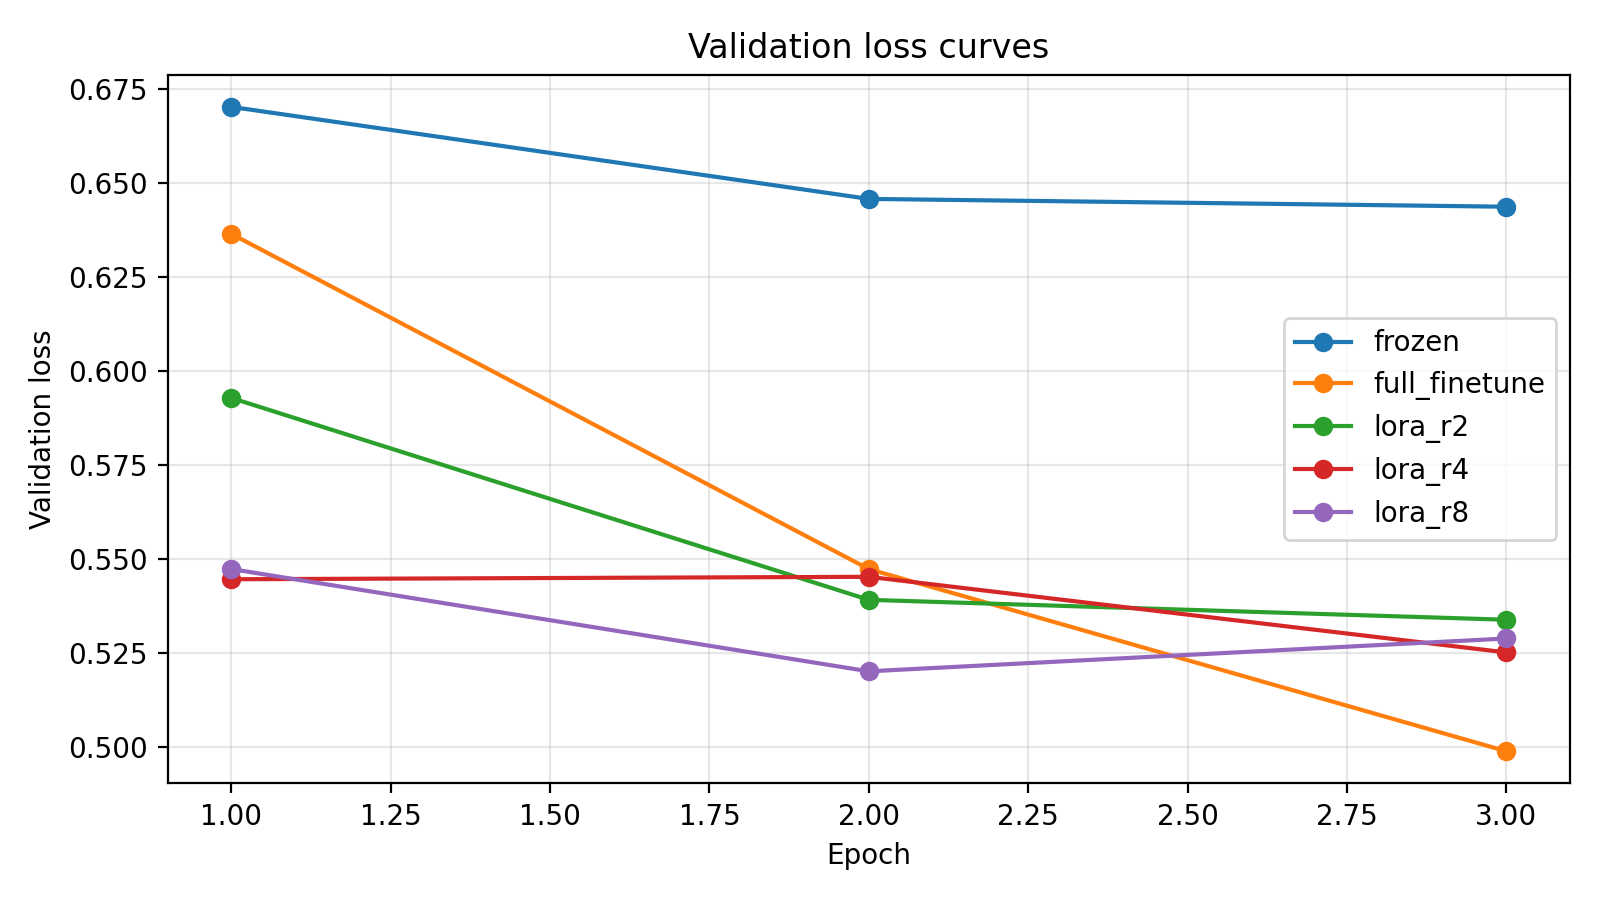

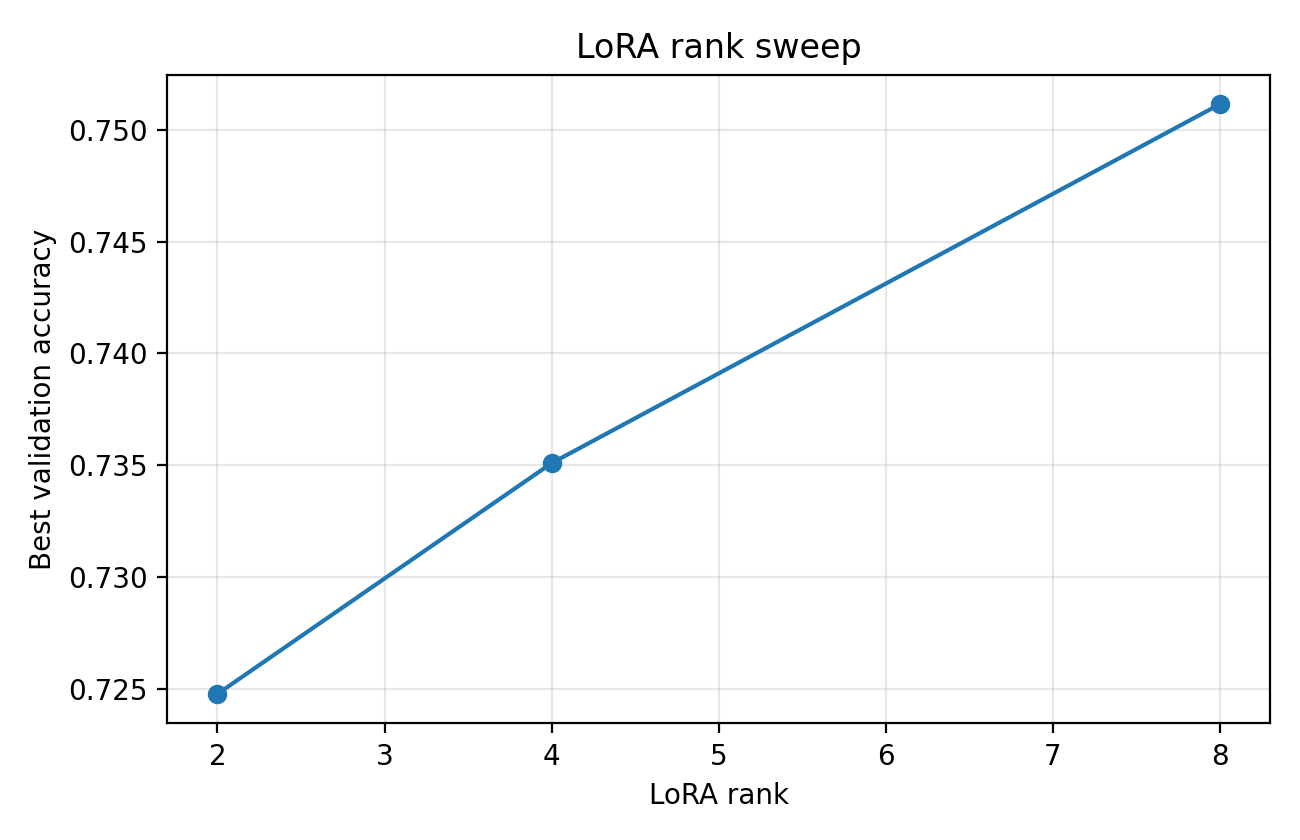

In [3]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

plots_dir = Path("results/plots")
display(pd.read_csv(plots_dir / "metrics.csv"))

for name in [
    "accuracy_vs_params.png",
    "trainable_params.png",
    "loss_curves.png",
    "accuracy_vs_rank.png",
]:
    path = plots_dir / name
    if path.exists():
        display(Image(filename=str(path)))

## Kết luận từ biểu đồ

Các hình cần được đọc cùng nhau:

- `accuracy_vs_params.png`: cho thấy LoRA nằm gần full fine-tuning về accuracy hơn frozen baseline, nhưng dùng ít tham số hơn rất nhiều.
- `trainable_params.png`: nhấn mạnh lợi ích compression của LoRA.
- `loss_curves.png`: cho biết động học học của từng cấu hình qua epoch.
- `accuracy_vs_rank.png`: dùng để thảo luận việc tăng rank không luôn cải thiện kết quả trong thí nghiệm nhỏ.

Các hình này đã được đưa vào phần `experiment_analysis.tex` của báo cáo.